# Imports

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import os
import itertools
import joblib

from sklearn.preprocessing import MinMaxScaler
import keras
from keras.models import Model
from keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout, Conv1D, BatchNormalization, MaxPooling1D, UpSampling1D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from pathlib import Path
import seaborn as sns
from sklearn.metrics import auc

2025-06-19 14:35:43.307991: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
TRAIN_FILEPATH = 'data_for_model/sound_levels_data.npy'
SILENT_EVENT_HOURS_1 = 'data_for_model/25_event_day.npy'
ONLY_INTRUSIONS = 'data_for_model/complete_intrusions.npy'
EVENT_TABLE_PATH = 'events_table.csv'
SCALERS_PATH = 'scalers'
MODELS_PATH = 'models'
THRESHOLDS_PATH = 'thresholds'

# Data Load Functions

In [3]:
def load_normalise_multi_loc(train_path, locations, scaler=None):
    """
    Load and normalize data from multiple non-consecutive locations.
    
    Args:
        train_path: Path to the .npy file
        locations: Single location (int) or list of locations
        scaler: Optional pre-fitted scaler
    
    Returns:
        X_normalised: Normalized data with shape (n_samples * n_locations, 59, 1)
        scaler: The scaler used for normalization
    """
    data = np.load(train_path)
    
    # Handle single location input
    if isinstance(locations, (int, float)):
        locations = [locations]
    
    # Convert locations to indices
    loc_indices = [int((loc - 1260) / 10) for loc in locations]
    
    # Extract data from specified locations
    # data shape: (1388, n_locations_total, 59)
    # We want: (1388 * len(locations), 59)
    selected_data = data[:, loc_indices, :]  # Shape: (1388, len(locations), 59)
    
    # Reshape to stack locations: (1388 * len(locations), 59)
    n_samples, n_selected_locs, n_timesteps = selected_data.shape
    # Flatten all data to 2D: (n_samples * n_locs * n_timesteps, 1)
    flat_data = selected_data.reshape(-1, 1)

    # Normalize with global min and max
    print(f"GLOBAL MIN: {flat_data.min()}, MAX: {flat_data.max()}")
    
    if scaler is not None:
        flat_normalised = scaler.transform(flat_data)
    else:
        scaler = MinMaxScaler()
        flat_normalised = scaler.fit_transform(flat_data)

    # Reshape back to (n_samples * n_locs, 59, 1)
    X_normalised = flat_normalised.reshape(n_samples * n_selected_locs, n_timesteps, 1)

    return X_normalised, scaler

In [4]:
def load_normalise_one_loc(train_path, location, scaler = None):

    data = np.load(train_path)

    loc = int((location - 1260)/10)
    data = data[:, loc, :]
    shape = data.shape
    flat_values = data.reshape(-1, 1)
    print(f"MIN:{np.min(flat_values)}, MAX:{np.max(flat_values)}")

    if scaler is not None:
        X_normalised = scaler.transform(flat_values)

    else:
        scaler = MinMaxScaler()
        X_normalised = scaler.fit_transform(flat_values)
        
    X_normalised = X_normalised.reshape(shape[0], shape[1], 1)


    return X_normalised, scaler

In [5]:
def load_test_one_loc(test_path, scaler, location, intrusions_only=False):

    loc = int((location - 1260)/10)
    data = np.load(test_path, allow_pickle=True)
    X_data = np.stack(data['data'], axis=0)

    if intrusions_only:
        X_file_refs = np.column_stack((data['row'], data['poi']))
        X_data = X_data[:, loc, :]
    else:
        X_file_refs = data['filename']
        if X_data.ndim == 4:
            X_data = X_data[:, loc, :, :]
        elif X_data.ndim == 3:
            X_data = X_data[:, loc, :]
    
    shape = X_data.shape

    flat_values = X_data.reshape(-1, 1)
    X_normalised = scaler.transform(flat_values)
    X_normalised = X_normalised.reshape(shape[0], shape[1], 1)

    return X_normalised, X_file_refs

# Building the Model

In [6]:
def build_model(X_train_shape, hidden_units, dropout, lr, loss, activation_func):
    """Building of the model. 

    This function builds an LSTM-Autoencoder model based on the specified hyperparemeters.

    Args:
        X_train_shape (tuple): Shape of the input training data (batch_size, timesteps, features).
        hidden_units (int): Number of LSTM units in the encoder and decoder.
        dropout (float): Dropout rate to apply after LSTM layers.
        lr (float): Learning rate for the optimizer.
    loss (str): Loss function to be used for training.

    Returns:
        tensorflow.keras.Model: Compiled LSTM-Autoencoder model.
    
    """

    input_shape = (X_train_shape[1],X_train_shape[2])  # (time_steps, features)

    # Encoder
    input_seq = Input(shape=input_shape)
    encoded = LSTM(hidden_units, activation=activation_func, return_sequences=True)(input_seq) 
    encoded = LSTM(hidden_units//2, activation=activation_func, return_sequences=False)(encoded)
    encoded = Dropout(dropout)(encoded)

    # Latent space
    latent_space = Dense(hidden_units, activation='relu')(encoded)

    # Decoder
    decoded = RepeatVector(input_shape[0])(latent_space)  
    decoded = LSTM(hidden_units//2, activation=activation_func, return_sequences=True)(decoded)
    decoded = LSTM(hidden_units, activation=activation_func, return_sequences=True)(decoded)
    decoded = Dropout(dropout)(decoded)

    decoded = TimeDistributed(Dense(input_shape[1]))(decoded)

    model = Model(input_seq, decoded)

    model.compile(optimizer=Adam(learning_rate=lr), loss=loss)

    model.summary()

    return model

# Plots Functions

In [7]:
def plot_original_reconstructed_one_loc(location, original_series, reconstructed_series, save_path=None):

    plt.figure(figsize=(12, 5))
    plt.plot(original_series, label="Original", linestyle="--", marker="o", color="royalblue")
    plt.plot(reconstructed_series, label="Reconstructed", linestyle="-", marker="s", color="darkorange")

    plt.xlabel("Time Step")
    plt.ylabel("Feature Value")
    plt.ylim((0, 1))
    plt.title(f"Original vs. Reconstructed Series (Location {location})")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()  
    else:
        plt.show()

In [8]:
def error_distribution(flat_reconstruction_error):

    plt.figure(figsize=(8, 5))
    plt.hist(flat_reconstruction_error, bins=50, color="royalblue", edgecolor="black", alpha=0.75)
    plt.xlabel("Reconstruction Error", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Distribution of Reconstruction Errors", fontsize=14)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()

In [9]:
def save_anomaly_plots(original, reconstructed, sample_indices, X_test_files, save_dir, title_prefix=""):

    os.makedirs(save_dir, exist_ok=True)

    for sample in sample_indices:
        event_id = X_test_files[sample, 0]
        locations = X_test_files[sample, 1].replace(" ", "")  

        safe_locations = locations.replace(",", "_")
        filename = f"{title_prefix.lower().replace(' ', '_')}_id_{event_id}_loc_{safe_locations}.png"

        plt.figure(figsize=(12, 5))
        plt.plot(original[sample, :, :], label='Original', linestyle="--", marker="o", color="royalblue")
        plt.plot(reconstructed[sample, :, :], label="Reconstructed", linestyle="-", marker="s", color="darkorange")
        plt.xlabel("Time Step")
        plt.ylabel("Feature Value")
        plt.title(f"Original vs. Reconstructed Series")
        plt.legend()
        plt.ylim((0, 1))
        plt.grid(True, linestyle="--", alpha=0.6)

        plt.savefig(os.path.join(save_dir, filename),  bbox_inches='tight')
        plt.close()

In [10]:
def plot_confusion_matrix(tp, fp, fn, tn, title='Confusion Matrix'):
    cm = np.array([[tp, fn],
                   [fp, tn]])

    labels = ['Positive', 'Negative']

    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                     xticklabels=labels, yticklabels=labels,
                     linewidths=0.5, linecolor='gray', square=True)


    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

In [11]:
def plot_roc_curves(*roc_results):
    plt.figure(figsize=(6, 6))
    
    for result in roc_results:
        label = f"{'Harsh' if result['harsh_testing'] else 'Soft'} Testing (AUC = {result['roc_auc']:.2f})"
        plt.plot(result['fprs'], result['tprs'], lw=2, label=label)
    
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


# Anomaly Detection Functions

In [12]:
def detect_anomalies_intrusions(absolute_errors, reconstructed, original, threshold, X_test_files, position, harsh_testing):
    per_event_meta = {}
    save_folder = "plots"

    for i, (max_error, meta_row) in enumerate(zip(absolute_errors, X_test_files)):
        event_id = meta_row[0]
        locations = [loc.strip() for loc in meta_row[1].split(',')]
        ground_truth = str(position) in locations

        # Initialize event if it doesn't exist
        if event_id not in per_event_meta:
            per_event_meta[event_id] = {
                "GT": int(ground_truth), 
                "Sample_IDs": set(),
                "Detected_Counter": 0
            }

        per_event_meta[event_id]["Sample_IDs"].add(i)

        # Detection logic
        if max_error > threshold:
            per_event_meta[event_id]["Detected_Counter"] += 1

            if ground_truth == False:
                if harsh_testing:
                    print(f"[FP] Event {event_id}")
                    filename = f"{save_folder}/false_positives/FP_{event_id}_pos_{position}_sample_{i}.png"
                    plot_original_reconstructed_one_loc(position, original[i], reconstructed[i], filename)
                else:
                    print(f"[SOFT TP] — Event {event_id}")
                    filename = f"{save_folder}/soft_true_positives/new_STP_{event_id}_pos_{position}_sample_{i}.png"
                    plot_original_reconstructed_one_loc(position, original[i], reconstructed[i], filename)

    # Find false negatives: ground truth = 1, but no detections
    for event_id, meta in per_event_meta.items():
        if (meta["GT"] == 1) and (meta["Detected_Counter"] == 0):
            print(f"[FN] Event {event_id}")
            for sid in meta["Sample_IDs"]:
                filename = f"{save_folder}/false_negatives/new_FN_{event_id}_pos_{position}_sample_{i}.png"
                plot_original_reconstructed_one_loc(position, original[sid], reconstructed[sid], filename)

    return per_event_meta



In [13]:
def detect_anomalies_normal(location, absolute_errors, reconstructed, original, threshold, X_test_files, plot=False):

    save_folder = "plots"
    os.makedirs(save_folder, exist_ok=True)

    for i, max_error in enumerate(absolute_errors):
        if max_error > threshold:
            
            if X_test_files is not None:
                print(f"Anomaly detected at sample {i} {X_test_files[i]}")
                filename = f"{save_folder}/false_positives/new_FP_{X_test_files[i]}_pos_{location}.png"
            else: 
                print(f"Anomaly detected at sample {i}")
                filename = f"{save_folder}/false_positives/new_FP_silent_{i}_pos_{location}.png"
            if plot:
                plot_original_reconstructed_one_loc(location, original[i], reconstructed[i], filename)
    

# Statistics/Evaluation

In [14]:
def get_performance(metadata, threshold, harsh_testing=True):
    TP, TN, FP, FN = 0, 0, 0, 0


    for _, row in metadata.iterrows():
        detected = row['maxAE'] > threshold
        true_label = row['true_label']
        includes_location = int(row['includes_location'])

        if (true_label == 1) and (includes_location == 1):
            if detected:
                TP += 1
            else:
                FN += 1
        
        elif (true_label) == 1 and (includes_location == 0):
            if detected:
                if harsh_testing:
                    FP += 1
                else:
                    TP +=1
            else:
                TN += 1
        
        elif true_label == 0:
            if detected: 
                FP +=1
            else:
                TN +=1


    return TP, FP, FN, TN


In [15]:
def compute_roc_auc(metadata, train_errors, harsh_testing=True):
    tpr_list = []
    fpr_list = []

    thresholds = np.percentile(train_errors, np.linspace(0, 100, 1000))

    for threshold in thresholds:
        TP, FP, FN, TN = get_performance(metadata, threshold, harsh_testing=harsh_testing)
        TPR = TP / (TP + FN) if (TP + FN) != 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) != 0 else 0
        tpr_list.append(TPR)
        fpr_list.append(FPR)

    roc_auc = auc(fpr_list, tpr_list)

    youden_index = np.array(tpr_list) - np.array(fpr_list)
    optimal_threshold_index = np.argmax(youden_index)
    optimal_threshold = thresholds[optimal_threshold_index]
    
    optimal_fpr = np.array(fpr_list)[optimal_threshold_index]
    optimal_tpr = np.array(tpr_list)[optimal_threshold_index]

    return {
        'roc_auc': roc_auc,
        'thresholds': thresholds,
        'fprs': fpr_list,
        'tprs': tpr_list,
        'harsh_testing': harsh_testing,
        'optimal_threshold': optimal_threshold,
        'optimal_fpr': optimal_fpr,
        'optimal_tpr': optimal_tpr,
    }

In [16]:
def evaluation_per_label(meta_table, event_table_path, threshold):

    per_label_meta = {}
    # load the event table
    event_table = pd.read_csv(event_table_path)
    # loop trhough meta table
    for idx, row in meta_table.iterrows():

        # get the event id/ row
        id = row['event']
        # get the row, extract the label
        label = event_table.iloc[int(id)]['label_anon']
        # create a data frame per label with happened/detected
        if label not in per_label_meta:
            per_label_meta[label] = {
                "Happened": 1,     
                "Detected": 0
            }
        else: 
            per_label_meta[label]["Happened"] += 1

        # if detected, detected +1
        if row['maxAE'] > threshold:
            per_label_meta[label]["Detected"] += 1

    labels = list(per_label_meta.keys())
    detected = [per_label_meta[label]["Detected"] for label in labels]  # True Positives
    missed = [per_label_meta[label]["Happened"] - per_label_meta[label]["Detected"] for label in labels]  # False Negatives

    x = range(len(labels))

    plt.figure(figsize=(10, 5))
    plt.bar(x, detected, label="True Positives", color="royalblue")
    plt.bar(x, missed, bottom=detected, label="False Negatives", color="darkorange")
    plt.xticks(x, labels, rotation=45)
    plt.ylabel("Sample Count")
    plt.title("Detection Performance per Label")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
        

# Data Load

In [17]:
LOCATIONS = [5860, 3540, 1430, 4350, 4290, 1680, 3800, 2680, 2100]
X_train, scaler = load_normalise_multi_loc(TRAIN_FILEPATH, LOCATIONS)

GLOBAL MIN: 4.356168497138321, MAX: 67.35533558920989


In [18]:
X_train.shape

(12492, 59, 1)

# Model Load

In [19]:
model = keras.models.load_model(f"{MODELS_PATH}/multi_loc_1.keras")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 59, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 59, 512)        │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 59, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 59, 256)        │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 59, 512)        │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 59, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 59, 1)          │           513 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,669,188 (33.07 MB)

 Trainable params: 4,334,593 (16.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,334,595 (16.54 MB)

# Model Training

In [ ]:
hidden_units = 512
learning_rate = 0.0005
dropout_rate = 0.2
loss = 'mae'
activation_function = 'tanh'

model = build_model(X_train.shape, hidden_units, dropout_rate, learning_rate, loss, activation_function)

In [ ]:
os.makedirs("checkpoints", exist_ok=True)
checkpoint_path = "checkpoints/model_epoch_{epoch:02d}_val_loss_{val_loss:.4f}.keras"

# Callback to save model checkpoints
checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=False,  # Set to True to only keep the best one
    save_weights_only=False,  # Set to True if you only want to save weights
    verbose=1
)

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Fit the model
model.fit(
    X_train, X_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, checkpoint_cb]
)

# Model Save

In [ ]:
model.save(f"{MODELS_PATH}/multi_loc_1.keras")

# Performance Inspection 

In [20]:
decoded = model.predict(X_train)

391/391 ━━━━━━━━━━━━━━━━━━━━ 88s 224ms/step


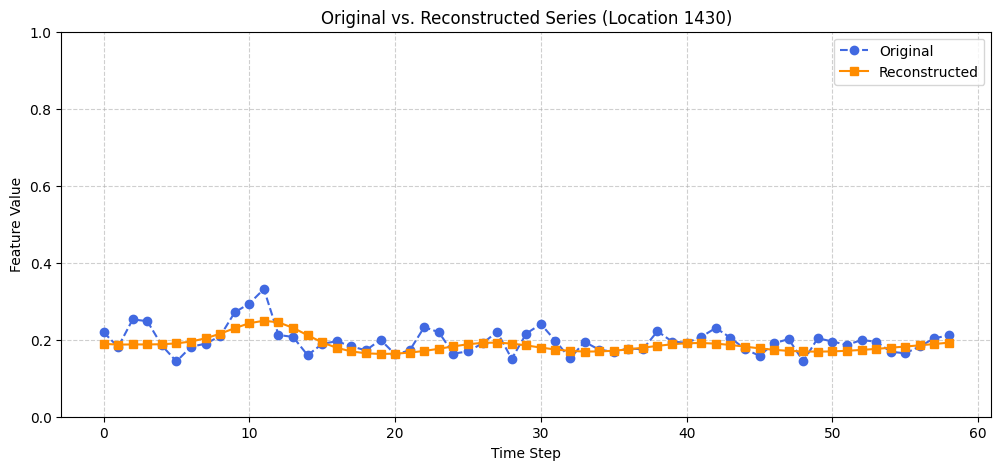

In [21]:
sample_id = 5
plot_original_reconstructed_one_loc(1430, X_train[sample_id], decoded[sample_id])

In [22]:
train_error = np.abs(decoded - X_train)

Mean: 0.026899004330644925, Min: 2.2479449468537638e-08, Max: 0.503296435361811, 99th Percentile: 0.12479930545880627


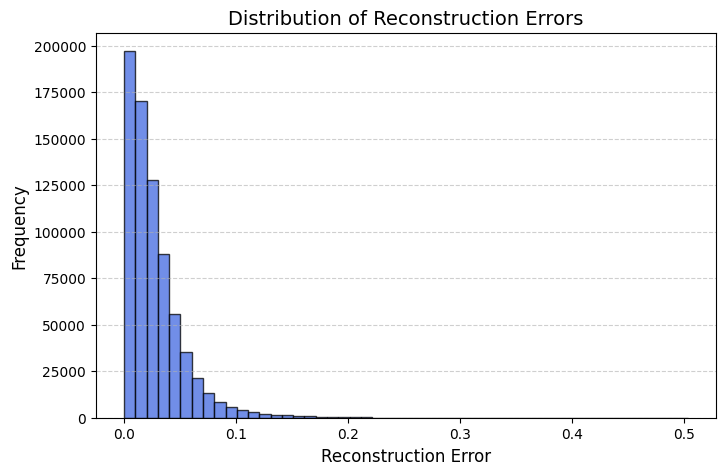

In [23]:
print(f"Mean: {np.mean(train_error)}, Min: {np.min(train_error)}, Max: {np.max(train_error)}, 99th Percentile: {np.percentile(train_error, 99)}")
error_distribution(train_error.flatten())

# Testing

## Silent Data (Normal Day)

In [24]:
LOCATION = 4220

In [25]:
X_test, _ = load_normalise_one_loc(TRAIN_FILEPATH, LOCATION, scaler)

MIN:7.802035863707778, MAX:52.59395251539629


In [26]:
X_test.shape

(1388, 59, 1)

### Model 

In [27]:
decoded_X_test = model.predict(X_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 218ms/step


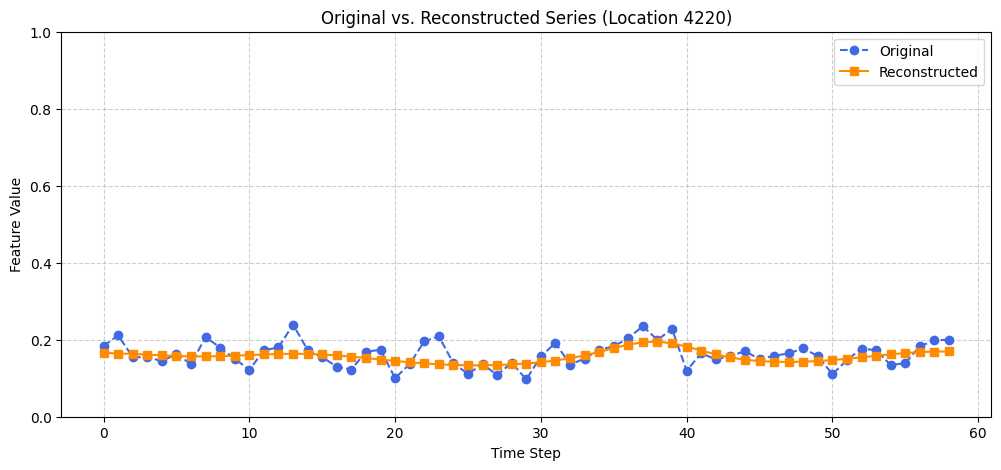

In [28]:
sample_id = 20
plot_original_reconstructed_one_loc(LOCATION, X_test[sample_id], decoded_X_test[sample_id])

In [29]:
X_test_error = abs(X_test - decoded_X_test)
X_test_error_max = np.max(X_test_error, axis=1).squeeze()
X_test_error_max.shape

(1388,)

In [30]:
np.random.seed(12)  # or any other integer you like
sample_indices = np.random.choice(len(X_test_error_max), size=250, replace=False)
sampled_errors = X_test_error_max[sample_indices]

Mean: 0.023591004816056606, Max: 0.4710339411688692, 99th Percentile: 0.08803962412818914


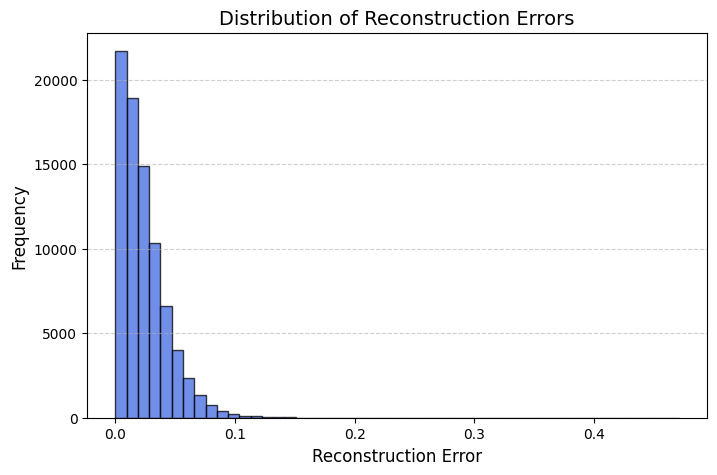

In [31]:
print(f"Mean: {np.mean(X_test_error)}, Max: {np.max(X_test_error)}, 99th Percentile: {np.percentile(X_test_error, 99)}")
error_distribution(X_test_error.flatten())

## Silent Data (Intrusion Day_1)

In [32]:
test_data, X_test_files = load_test_one_loc(SILENT_EVENT_HOURS_1, scaler, LOCATION)
silent_test = test_data[:420, :, :]
silent_X_test_files = X_test_files[:420]

### Baseline Approach

In [33]:
anomalies_idx = np.where(silent_test > 1)
[len(a) for a in anomalies_idx]

[0, 0, 0]

### Model 

In [34]:
decoded_test_silent = model.predict(silent_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step


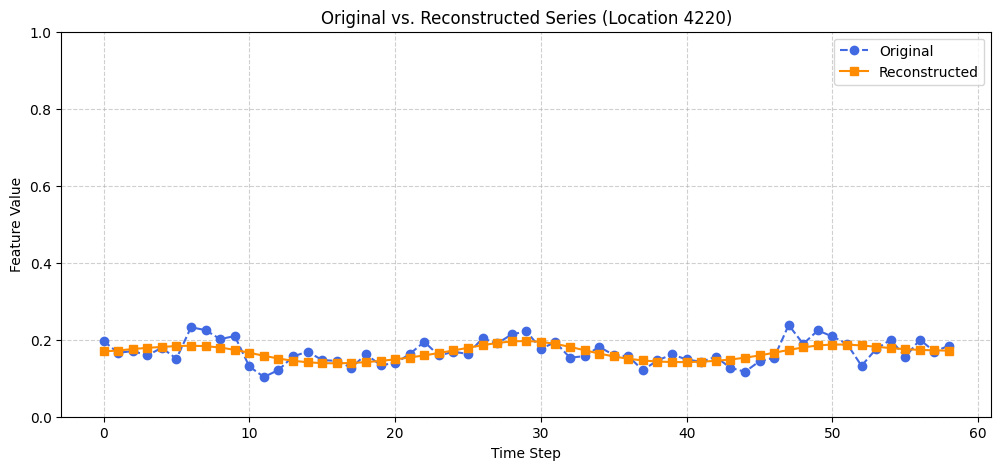

In [35]:
sample_id = 200
plot_original_reconstructed_one_loc(LOCATION, silent_test[sample_id], decoded_test_silent[sample_id])

In [36]:
silent_test_error = abs(silent_test - decoded_test_silent)
silent_test_error_max = np.max(silent_test_error, axis=1).squeeze()
silent_test_error_max.shape

(420,)

Mean: 0.02060026791063969, Max: 0.19695063481579383, 99th Percentile: 0.07274791310720377


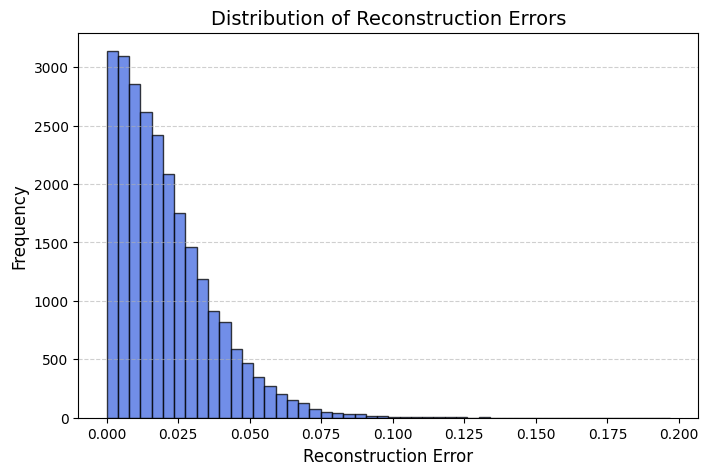

In [37]:
print(f"Mean: {np.mean(silent_test_error)}, Max: {np.max(silent_test_error)}, 99th Percentile: {np.percentile(silent_test_error, 99)}")
error_distribution(silent_test_error.flatten())

In [38]:
np.percentile(np.concatenate([silent_test_error, X_test_error]), 99)

np.float64(0.08502881037682229)

## Intrusion Data

In [39]:
intrusion_test_data, event_row = load_test_one_loc(ONLY_INTRUSIONS, scaler, LOCATION, True)

### Baseline Approach

In [40]:
anomalies_idx_intrusions = np.where(intrusion_test_data > 1)
[len(a) for a in anomalies_idx_intrusions]

[0, 0, 0]

### Model

In [41]:
decoded_test_intrusion = model.predict(intrusion_test_data)

78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 225ms/step


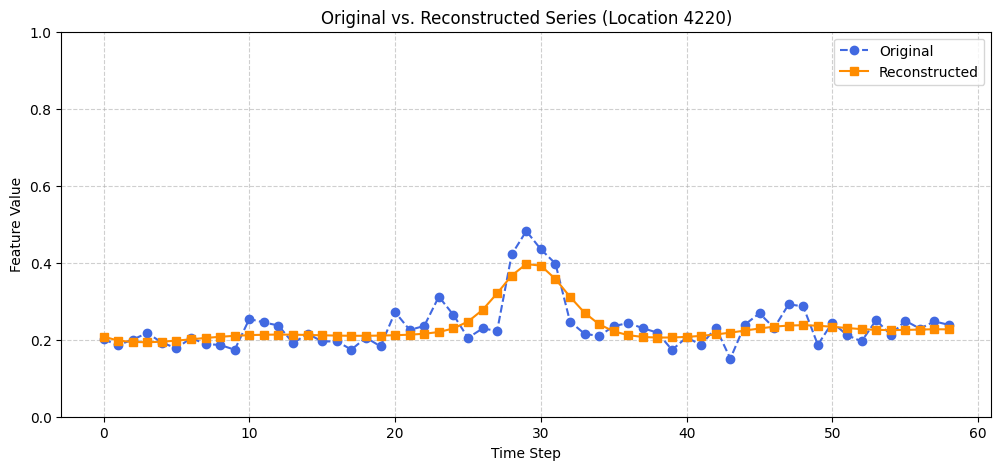

In [42]:
sample_id = 400
plot_original_reconstructed_one_loc(LOCATION, intrusion_test_data[sample_id], decoded_test_intrusion[sample_id])

In [43]:
intrusion_test_error = abs(intrusion_test_data - decoded_test_intrusion)

In [44]:
max_intrusion_test_error = np.max(intrusion_test_error, axis=1).squeeze()
max_intrusion_test_error.shape

(2466,)

Mean: 0.034826768351544427, Max: 0.5221570889721991, 99th Percentile: 0.23552183921919412


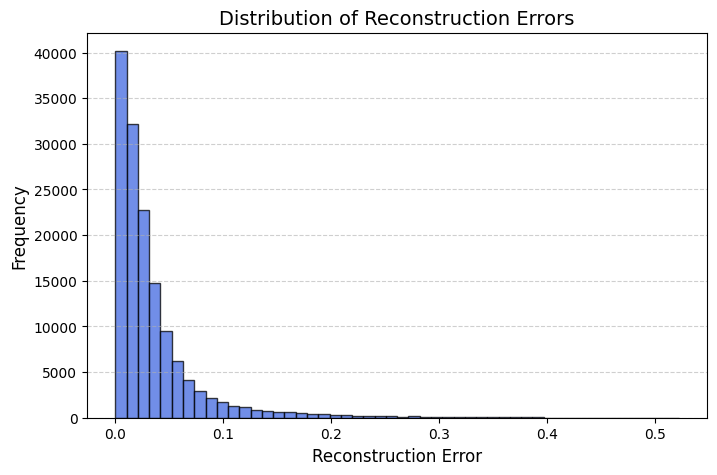

In [45]:
print(f"Mean: {np.mean(intrusion_test_error)}, Max: {np.max(intrusion_test_error)}, 99th Percentile: {np.percentile(intrusion_test_error, 99)}")
error_distribution(intrusion_test_error.flatten())

# AUC ROC Method on Combined Data

## Combine Data

In [50]:
X_test_meta_data = pd.DataFrame({'event': np.array([f"Silent_sample_{i}" for i in range(sampled_errors.shape[0])]), 
                                 'maxAE': sampled_errors, 
                                 'true_label': np.zeros(sampled_errors.shape, dtype=int), 
                                 'includes_location': np.ones(sampled_errors.shape, dtype=int)})

In [51]:
silent_meta_data = pd.DataFrame({'event': silent_X_test_files, 
                                 'maxAE': silent_test_error_max, 
                                 'true_label': np.zeros(silent_test_error_max.shape, dtype=int),
                                 'includes_location': np.ones(silent_test_error_max.shape, dtype=int)})

In [52]:
event_row_new = np.copy(event_row)
event_row_new[:, 1] = (np.char.find(event_row[:, 1], str(LOCATION)) != -1).astype(int)
intrusions_meta_data = pd.DataFrame({'event': event_row_new[:, 0], 
                                    'maxAE': max_intrusion_test_error, 
                                    'true_label': np.ones(max_intrusion_test_error.shape, dtype=int), 
                                    'includes_location': event_row_new[:, 1].astype(int)})
intrusions_meta_data = intrusions_meta_data.groupby(['event'], as_index=False).max()

In [53]:
combined_data_frame = pd.concat([X_test_meta_data, silent_meta_data, intrusions_meta_data], ignore_index=True)

## Evaluation

In [54]:
roc_result_harsh = compute_roc_auc(combined_data_frame, train_error, True)
roc_result_soft = compute_roc_auc(combined_data_frame, train_error, False)

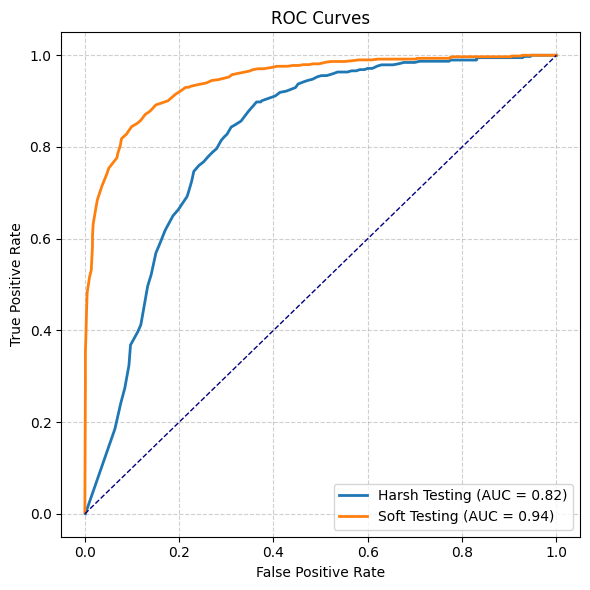

In [55]:
plot_roc_curves(roc_result_harsh, roc_result_soft)

In [56]:
threshold_soft = roc_result_soft['optimal_threshold']
threshold_harsh = roc_result_harsh['optimal_threshold']
print(threshold_soft, threshold_harsh)

0.09839540598993347 0.08579394158372818


In [57]:
np.savez(f"thresholds/thresholds_multi.npz", soft=threshold_soft, harsh=threshold_harsh)

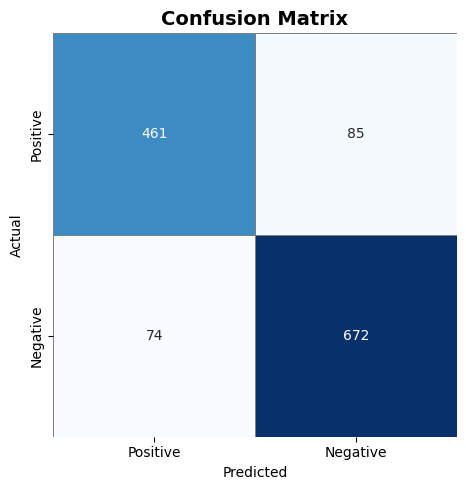

In [58]:
TP, FP, FN, TN = get_performance(combined_data_frame, threshold_soft, False)
plot_confusion_matrix(TP, FP, FN, TN)

In [59]:
joblib.dump(scaler, f'scalers/scaler_multi.pkl')

['scalers/scaler_multi.pkl']

# Anomaly Detection

In [ ]:
meta_peformance = detect_anomalies_intrusions(max_intrusion_test_error, decoded_test_intrusion, intrusion_test_data, threshold_soft, event_row, LOCATION, False)

In [ ]:
detect_anomalies_normal(LOCATION, silent_test_error_max, decoded_test_silent, silent_test, threshold_soft, silent_X_test_files, plot=True)

In [ ]:
evaluation_per_label(intrusions_meta_data, EVENT_TABLE_PATH, threshold_soft)